In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/imran495/data-cleaning-etl-desi-dairy-farm/__results__.html
/kaggle/input/notebooks/imran495/data-cleaning-etl-desi-dairy-farm/__notebook__.ipynb
/kaggle/input/notebooks/imran495/data-cleaning-etl-desi-dairy-farm/Desi_Farm_Expenses.csv
/kaggle/input/notebooks/imran495/data-cleaning-etl-desi-dairy-farm/__output__.json
/kaggle/input/notebooks/imran495/data-cleaning-etl-desi-dairy-farm/Desi_Farm_Income.csv
/kaggle/input/notebooks/imran495/data-cleaning-etl-desi-dairy-farm/custom.css
/kaggle/input/datasets/imran495/dairy-farm-operations-and-financial-ledger-20192025/Farm 2019 Expenses vs. Income july to december.xlsx
/kaggle/input/datasets/imran495/dairy-farm-operations-and-financial-ledger-20192025/Farm Expenses Jan- June 2021.xlsx
/kaggle/input/datasets/imran495/dairy-farm-operations-and-financial-ledger-20192025/Desi Farm Report July to Dec 2023.xlsx
/kaggle/input/datasets/imran495/dairy-farm-operations-and-financial-ledger-20192025/Farm Expenses July-Dec 2020.xl

# 🐄 Desi Farm: Business Case Study & Exploratory Data Analysis

## 1. Introduction & Business Context

### The Situation
Desi Farm (SMC-Private) Limited has been actively operating and maintaining daily financial ledgers over a 7-year period (2019–2025). The farm's management has meticulously recorded every transaction, ranging from daily operational expenses (feed, fodder, veterinary care, and maintenance) to capital asset management (buying and selling of livestock). 

### The Concern (Why are we doing this study?)
While the raw financial ledgers accurately track *what* money was spent and earned, they do not automatically explain *how efficiently* the farm is operating. In the dairy and agricultural sector, profit margins are highly sensitive to seasonal changes, inflation in feed costs, and the lifecycle of the livestock. 
Relying solely on a raw ledger makes it difficult to answer critical business questions:
* Are the daily operational costs (like feed and electricity) eating into the milk revenue?
* Is the farm actually profitable on a month-to-month basis, or are capital asset sales (selling animals) masking operational losses?
* Which expenses are the biggest financial drains, and how do they fluctuate throughout the year?

### The Objective
The goal of this Exploratory Data Analysis (EDA) is to transform 7 years of unstructured ledger entries into actionable business intelligence. By separating day-to-day operational cash flows from livestock capital gains, we aim to uncover the true net profitability of Desi Farm. The insights derived from this study will help identify cost-saving opportunities, optimize feed inventory, and provide a clear financial roadmap for future agricultural investments.

In [2]:
import pandas as pd

# 1. Load data using exact file paths
expenses_path = '/kaggle/input/notebooks/imran495/data-cleaning-etl-desi-dairy-farm/Desi_Farm_Expenses.csv'
income_path = '/kaggle/input/notebooks/imran495/data-cleaning-etl-desi-dairy-farm/Desi_Farm_Income.csv'

df_expenses = pd.read_csv(expenses_path)
df_income = pd.read_csv(income_path)

# 2. Clean and standardize data types (Dates and Numbers)
df_expenses['date'] = pd.to_datetime(df_expenses['date'], errors='coerce')
df_income['date'] = pd.to_datetime(df_income['date'], errors='coerce')

df_expenses['amount'] = pd.to_numeric(df_expenses['amount'], errors='coerce').fillna(0)
df_income['amount'] = pd.to_numeric(df_income['amount'], errors='coerce').fillna(0)

# 3. Create a 'month_year' column to group data by month
df_expenses['month_year'] = df_expenses['date'].dt.to_period('M')
df_income['month_year'] = df_income['date'].dt.to_period('M')

# 4. Aggregate monthly totals for both Income and Expenses
monthly_expenses = df_expenses.groupby('month_year')['amount'].sum().reset_index(name='total_expense')
monthly_income = df_income.groupby('month_year')['amount'].sum().reset_index(name='total_income')

# 5. Merge into a final monthly summary table and calculate Net Profit
monthly_finance = pd.merge(monthly_income, monthly_expenses, on='month_year', how='outer').fillna(0)
monthly_finance['net_profit'] = monthly_finance['total_income'] - monthly_finance['total_expense']

# 6. Sort chronologically from July 2019 to October 2025
monthly_finance = monthly_finance.sort_values('month_year').reset_index(drop=True)

print("✅ Monthly Financial Data Successfully Prepared!")
display(monthly_finance.head(20))


✅ Monthly Financial Data Successfully Prepared!


,month_year,total_income,total_expense,net_profit
0,2019-06,0.0,39000.0,-39000.0
1,2019-07,0.0,32750.0,-32750.0
2,2019-08,0.0,61800.0,-61800.0
3,2019-09,0.0,36800.0,-36800.0
4,2019-10,0.0,64080.0,-64080.0
5,2019-11,0.0,127410.0,-127410.0
6,2019-12,444000.0,542411.0,-98411.0
7,2020-01,126690.0,190968.0,-64278.0
8,2020-02,117430.0,129801.0,-12371.0
9,2020-03,133470.0,220388.0,-86918.0


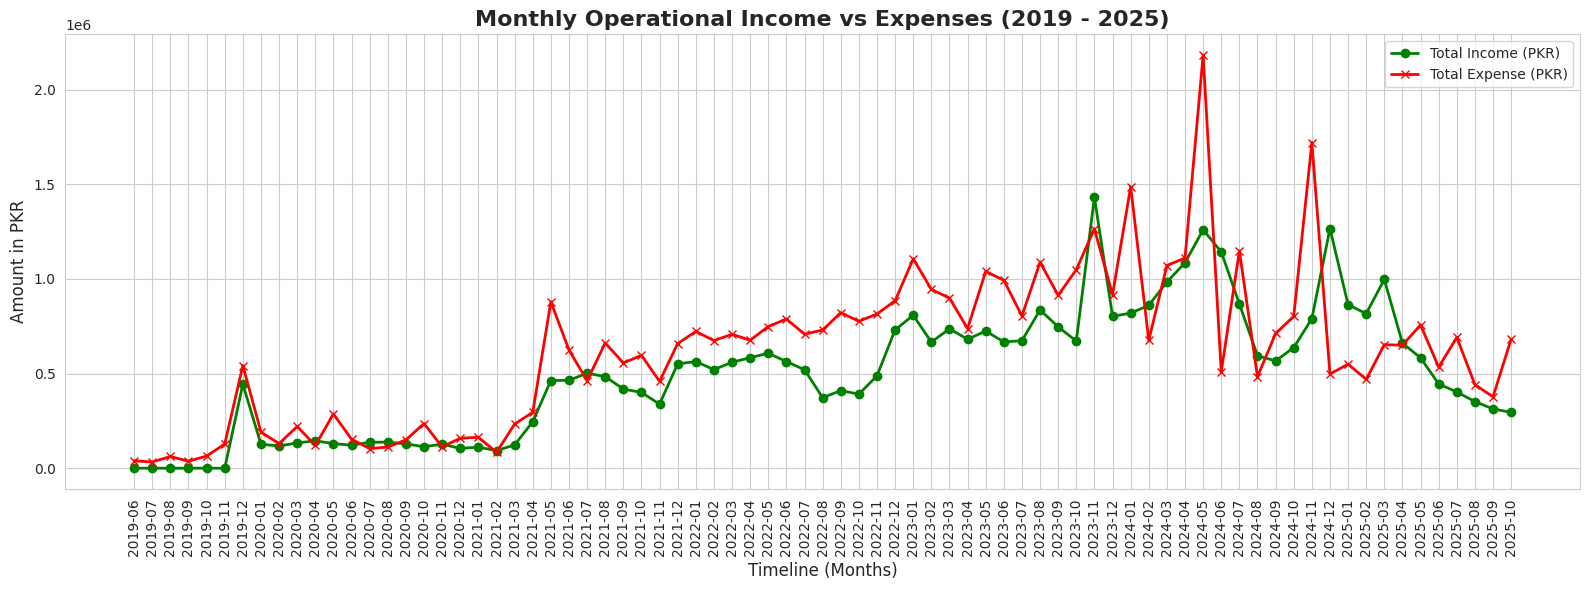

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'month_year' to string format so it plots correctly on the X-axis
monthly_finance['month_str'] = monthly_finance['month_year'].astype(str)

# Set the style and size of the graph
plt.figure(figsize=(16, 6))
sns.set_style("whitegrid")

# Plot Total Income vs Total Expense over time
plt.plot(monthly_finance['month_str'], monthly_finance['total_income'], label='Total Income (PKR)', color='green', marker='o', linewidth=2)
plt.plot(monthly_finance['month_str'], monthly_finance['total_expense'], label='Total Expense (PKR)', color='red', marker='x', linewidth=2)

# Customize the chart labels and title
plt.title('Monthly Operational Income vs Expenses (2019 - 2025)', fontsize=16, fontweight='bold')
plt.xlabel('Timeline (Months)', fontsize=12)
plt.ylabel('Amount in PKR', fontsize=12)
plt.xticks(rotation=90) # Rotate month labels so they are easy to read
plt.legend()
plt.tight_layout()

# Show the clean financial graph
plt.show()


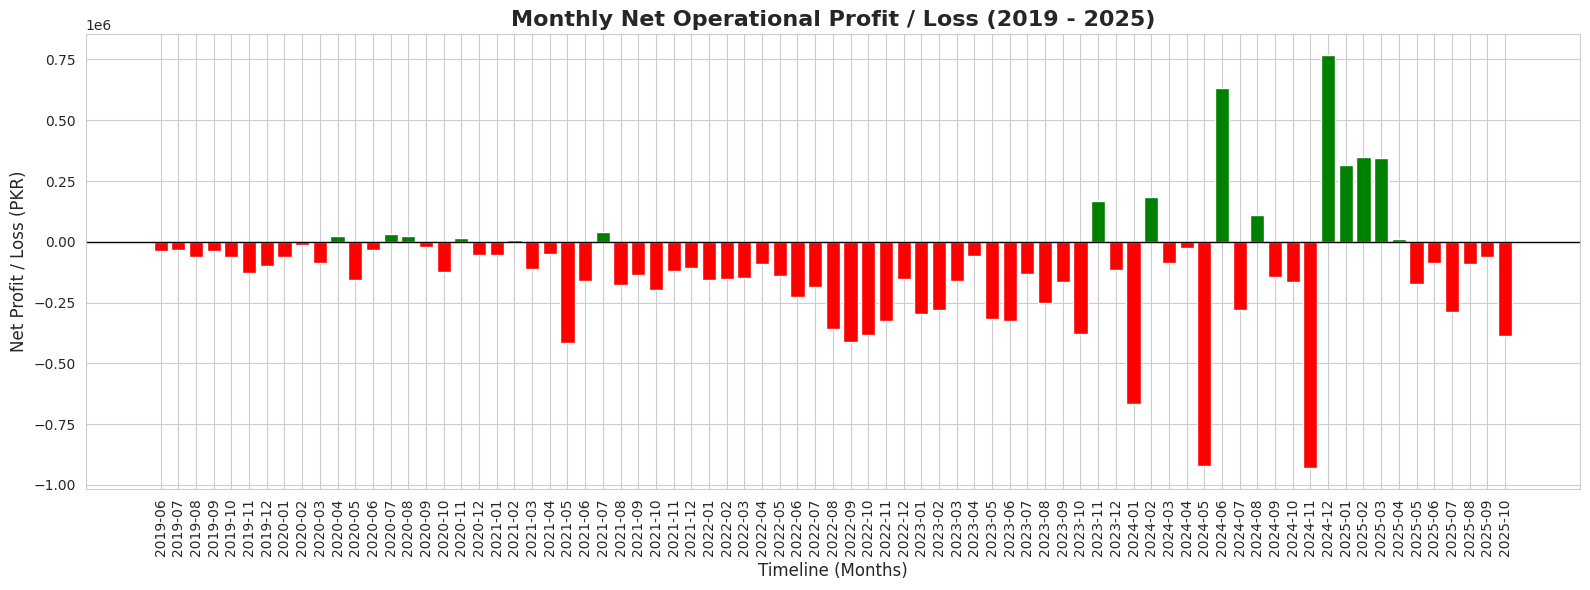

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Set the figure size for the dashboard
plt.figure(figsize=(16, 6))

# Define conditional colors: Green for profit (>= 0), Red for loss (< 0)
colors = ['green' if val >= 0 else 'red' for val in monthly_finance['net_profit']]

# Create a bar chart to visualize Net Profit and Loss
plt.bar(monthly_finance['month_str'], monthly_finance['net_profit'], color=colors)

# Add professional title and axis labels
plt.title('Monthly Net Operational Profit / Loss (2019 - 2025)', fontsize=16, fontweight='bold')
plt.xlabel('Timeline (Months)', fontsize=12)
plt.ylabel('Net Profit / Loss (PKR)', fontsize=12)

# Rotate x-axis month labels for better readability
plt.xticks(rotation=90) 

# Add a distinct horizontal baseline at zero to separate profit from loss
plt.axhline(0, color='black', linewidth=1) 

# Adjust layout to prevent label clipping
plt.tight_layout()

# Display the generated chart
plt.show()
